<a href="https://colab.research.google.com/github/apanish-cell/Learning-DeepLearning/blob/main/fashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Tutorial: Fashion MNIST with Convolutional Neural Networks (CNNs)

Welcome to this hands-on tutorial on deep learning with PyTorch using the Fashion MNIST dataset. This notebook will guide you through the process of building a Convolutional Neural Network (CNN) to classify fashion items.

## Prerequisites

Before diving into the tutorial, ensure you have the following prerequisites installed and set up:

1. **Python**: This tutorial requires Python 3.x. Python is the primary language we'll be using.
2. **PyTorch & torchvision**: PyTorch is an open-source machine learning library, and torchvision offers datasets and models for computer vision.
3. **Jupyter Notebook**: The interactive environment where this tutorial is presented.
4. **NumPy**: A library for numerical operations in Python.
5. **scikit-learn**: Machine learning library in Python. We'll use it for performance metrics.
6. **Seaborn & Matplotlib**: Visualization libraries in Python.
7. **CUDA (Optional)**: If you have a compatible NVIDIA GPU, you can install CUDA for GPU acceleration with PyTorch.

You can install the above prerequisites using the following commands:

In [1]:
# Install necessary libraries and dependencies
%pip install numpy
%pip install torch torchvision
%pip install jupyter
%pip install scikit-learn
%pip install seaborn matplotlib
# !pip install numpy
# !pip install torch torchvision
# !pip install jupyter
# !pip install scikit-learn
# !pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.2 MB/s eta 0:00:00


## Setup and Installation

Let's start by importing the necessary libraries and modules required for our tutorial.


In [1]:
# PyTorch Tutorial: Fashion MNIST with Convolutional Neural Networks (CNNs)

# Welcome to this hands-on tutorial on deep learning with PyTorch using the Fashion MNIST dataset.
# This notebook will guide you through the process of building a Convolutional Neural Network (CNN) to classify fashion items.

# Setup and Installation

# Importing essential libraries and modules for deep learning and visualization
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Setting up device for GPU usage if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}.")

device


Running on cuda.


device(type='cuda')

## Understanding the Fashion MNIST Dataset

The Fashion MNIST dataset is a collection of grayscale images of 10 fashion categories, each of size 28x28 pixels. It's used as a drop-in replacement for the classic MNIST dataset. It serves as a more challenging classification problem than the regular MNIST digit dataset due to the similarities in clothing items.

![Fashion MNIST Sample](https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/fashion-mnist-sprite.png)

Each image in the dataset corresponds to a label from 0-9, representing the ten categories:

| Label | Description |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


## Data Loading and Preprocessing

To process and use the Fashion MNIST dataset with PyTorch, we'll utilize the `torchvision` module, which provides a convenient API to load and transform datasets.

## Understanding PyTorch Utilities

### torchvision

`torchvision` is a library within the PyTorch ecosystem that provides a suite of utilities for computer vision. It offers:

- Pretrained models (like ResNet, VGG, and AlexNet).
- Popular datasets and transformations to preprocess these datasets.
- Utilities to create custom datasets and data loaders.

In this tutorial, we are primarily using `torchvision` to access the Fashion MNIST dataset and apply transformations to the images.

### torch.utils

`torch.utils` is a utility module in PyTorch that offers several sub-modules to assist in various tasks. One of its most used sub-modules is `data`, which helps handle datasets and provides tools to load and preprocess data efficiently.

### DataLoader

`DataLoader` is a class within `torch.utils.data` that wraps a dataset and provides mini-batches of the data. It offers:

- Batching the data: Instead of training on the entire dataset, we often train on small batches of data for better optimization and faster training.
- Shuffling: Randomly reordering the training data at the start of each epoch to reduce model variance.
- Parallel loading: Using multi-threading to prepare batches in the background, ensuring that the GPU/ CPU stays busy.

In the context of this tutorial, `DataLoader` is used to load the Fashion MNIST dataset in batches, shuffle them, and ensure efficient loading using multiple workers.

Now, let's dive into the provided code and understand it line by line.



In [2]:
# Import the necessary transformations module from torchvision
import torchvision.transforms as transforms

# Define a transformation pipeline.
# Here, we're only converting the images to PyTorch tensor format.
transform = transforms.Compose([transforms.ToTensor()])

# Using torchvision, load the Fashion MNIST training dataset.
# root specifies the directory where the dataset will be stored.
# train=True indicates that we want the training dataset.
# download=True will download the dataset if it's not present in the specified root directory.
# transform applies the defined transformations to the images.
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

# Create a data loader for the training set.
# It will provide batches of data, in this case, batches of size 4.
# shuffle=True ensures that the data is shuffled at the start of each epoch.
# num_workers=2 indicates that two subprocesses will be used for data loading.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

# Similarly, load the Fashion MNIST test dataset.
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

# Define the class labels for the Fashion MNIST dataset.
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.10MB/s]


## Convolutional Neural Networks (CNNs)

Convolutional Neural Networks (CNNs) have revolutionized the field of computer vision. They are specifically designed to recognize visual patterns directly from pixel images with minimal preprocessing. CNNs are hierarchical models where neurons in one layer connect to neurons in the next layer in a limited fashion, somewhat like the receptive field in human vision.

![CNN Architecture](https://miro.medium.com/max/2824/1*uAeANQIOQPqWZnnuH-VEyw.jpeg)

A typical CNN architecture consists of:
1. **Convolutional Layers:** Apply convolution operation on the input layer to detect features.
2. **Activation Layers:** Introduce non-linearity to the model (typically ReLU).
3. **Pooling Layers:** Perform down-sampling operations to reduce dimensionality.
4. **Fully Connected Layers:** After several convolutional and pooling layers, the high-level reasoning in the neural network happens via fully connected layers.

Let's design a basic CNN for our dataset.


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        # Input: [batch_size, 1, 28, 28]
        self.conv1 = nn.Conv2d(1, 32, 3)  # Output: [batch_size, 32, 26, 26]

        # Input: [batch_size, 32, 26, 26]
        self.conv2 = nn.Conv2d(32, 64, 3) # Output: [batch_size, 64, 11, 11]

        self.fc1 = nn.Linear(64 * 5 * 5, 128)  # Flattening: [batch_size, 64*5*5]
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Input: [batch_size, 1, 28, 28]
        x = F.relu(self.conv1(x))
        # Shape: [batch_size, 32, 26, 26]
        x = F.max_pool2d(x, 2)
        # Shape: [batch_size, 32, 13, 13]

        x = F.relu(self.conv2(x))
        # Shape: [batch_size, 64, 11, 11]
        x = F.max_pool2d(x, 2)
        # Shape: [batch_size, 64, 5, 5]

        x = x.view(-1, 64 * 5 * 5) # Flattening
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

## Training and Evaluation

### 1. Model Instantiation

We first create an instance of our model and transfer it to the appropriate device (either CPU or GPU).

In [7]:
model = BasicCNN().to("cuda")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params}")

Total Parameters: 225034


### 2. Optimizer and Loss Function

For training the neural network, we need an optimizer and a loss function. The optimizer updates the model parameters (weights and biases) to minimize the loss.

- **Optimizer**: The Adam optimizer is commonly used and adapts the learning rate during training.
- **Loss Function**: Since this is a classification task, we use the Cross Entropy Loss.


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


## Understanding Optimizers and Loss Functions

### Optimizers:

Optimizers are algorithms used to adjust the model's weights based on the gradient of the loss function. The goal is to minimize the loss. There are several optimizers available:

1. **SGD (Stochastic Gradient Descent)**: This is the basic form of the gradient descent algorithm. It updates the model's weights using the gradient of the loss function with respect to each weight.
    - Use: `torch.optim.SGD(model.parameters(), lr=learning_rate)`

2. **Momentum**: A variant of SGD that takes into account the previous steps, helping accelerate convergence and avoid local minima.
    - Use: `torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)`

3. **Adam**: Combines the advantages of two other extensions of SGD, namely AdaGrad and RMSProp. It adjusts the learning rate of each weight based on the historical gradient information.
    - Use: `torch.optim.Adam(model.parameters(), lr=learning_rate)`

4. **RMSProp**: Maintains a moving average of the squared gradient and divides the gradient by the root of this average.
    - Use: `torch.optim.RMSprop(model.parameters(), lr=learning_rate)`

### Loss Functions for Classification:

1. **Cross-Entropy Loss**: Used for multi-class classification. It quantifies the difference between the predicted probability distribution and the actual distribution.
    - Use: `nn.CrossEntropyLoss()`

2. **Binary Cross-Entropy Loss**: Specifically for binary classification tasks.
    - Use: `nn.BCELoss()`

3. **Hinge Loss (or Margin Loss)**: Used for "maximum-margin" classification, mostly for SVMs.
    - Use: `nn.HingeEmbeddingLoss()`

### Identifying the Task:

- **Classification**: In classification, the goal is to predict a class label for an input data point. If the dataset provides categorical labels (e.g., 'cat', 'dog', 'shirt', 'sandal'), it's a classification task.

- **Segmentation**: The goal in segmentation is to classify each pixel in an image. If the dataset provides images with colored regions indicating different objects or features, it's a segmentation task.

- **Regression**: Regression problems involve predicting a continuous value. If the dataset provides numerical values (e.g., house prices, stock prices) as labels, it's a regression task.

To discern between tasks, examine the dataset's labels and the problem's requirements. For example, if you're trying to predict an item's category from an image, it's classification. If predicting numerical values from features, it's regression.


## 3. Training Loop (Explained)

Training a neural network involves iteratively updating its weights to minimize the loss function. This process is typically achieved using gradient descent optimization algorithms. Here's an in-depth explanation of the training loop:

1. **Epochs**: An epoch represents one complete forward and backward pass of all the training examples. The number of epochs (`num_epochs`) is the number of times the learning algorithm will work through the entire training dataset. Usually a custom hyperparameter.

2. **Model Training Mode**: Neural networks can operate in different modes - training and evaluation. Some layers, like dropout, behave differently in these modes. Setting the model to training mode ensures that layers like dropout function correctly.

3. **Batch Processing**: Instead of updating weights after every training example (stochastic gradient descent) or after the entire dataset (batch gradient descent), we often update weights after a set of training examples known as a batch.

4. **Zeroing Gradients**: In PyTorch, gradients accumulate by default. Before calculating the new gradients in the current batch, we need to set the previous gradients to zero.

5. **Forward Pass**: The input data (images) are passed through the network, layer by layer, until we get the output. This process is called the forward pass.

6. **Calculate Loss**: Once we have the network's predictions (outputs), we compare them to the true labels using a loss function. This gives a measure of how well the network's predictions match the actual labels.

7. **Backward Pass**: To update the weights, we need to know the gradient of the loss function with respect to each weight. The backward pass computes these gradients.

8. **Update Weights**: The optimizer updates the weights based on the gradients computed in the backward pass.

This loop (forward pass, loss computation, backward pass, weight update) is repeated for every batch in the dataset, and the whole process is repeated for the specified number of epochs.



In [ ]:
# Number of complete passes through the dataset
num_epochs = 5

# Start the training loop
for epoch in range(num_epochs):
    # Set the model to training mode
    model.train()

    # Iterate over each batch of the training data
    for images, labels in trainloader:
        # Move the images and labels to the computational device (CPU or GPU)
        images, labels = images.to(device), labels.to(device)

        # Clear the gradients from the previous iteration
        optimizer.zero_grad()

        # Forward pass: Pass the images through the model to get the predicted outputs
        outputs = model(images)

        # Compute the loss between the predicted outputs and the true labels
        loss = criterion(outputs, labels)

        # Backward pass: Compute the gradient of the loss w.r.t. model parameters
        loss.backward()

        # Update the model parameters
        optimizer.step()


## Evaluation

Once our model is trained, it's crucial to evaluate its performance on unseen data. We'll:

1. Generate predictions for the test set.
2. Compute the overall accuracy.
3. Examine the model's performance in detail using a confusion matrix and classification report.

These tools will provide insights into specific areas where the model excels or might need improvement.

**Note:** We don't want to compute gradients, so we use `torch.no_grad()`.

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.83      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.81      0.86      0.83      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.87      0.76      0.81      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.67      0.76      0.71      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



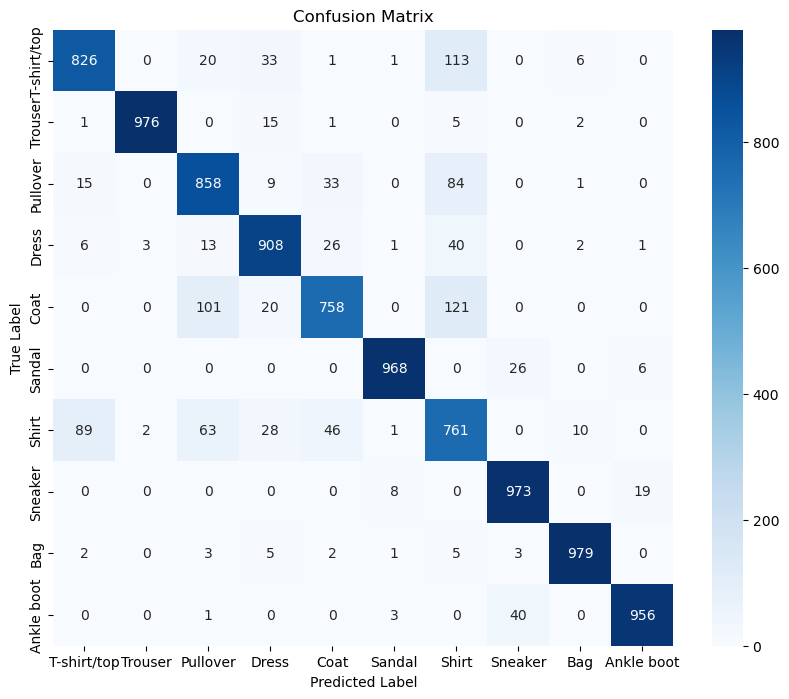

In [ ]:
# Import necessary libraries:
# numpy for numerical operations
# sklearn.metrics for evaluation metrics like classification report and confusion matrix
# seaborn and matplotlib for data visualization
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set the model to evaluation mode. This is important as certain layers like dropout behave differently during training and evaluation.
model.eval()

# Lists to store all predictions and true labels
all_preds = []
all_labels = []

# We don't want to compute gradients during evaluation, hence wrap the code inside torch.no_grad()
with torch.no_grad():
    # Iterate over all batches in the test loader
    for images, labels in testloader:
        # Transfer images and labels to the computational device (either CPU or GPU)
        images, labels = images.to(device), labels.to(device)

        # Pass the images through the model to get predictions
        outputs = model(images)

        # Get the class with the maximum probability as the predicted class
        _, predicted = torch.max(outputs, 1)

        # Extend the all_preds list with predictions from this batch
        all_preds.extend(predicted.cpu().numpy())

        # Extend the all_labels list with true labels from this batch
        all_labels.extend(labels.cpu().numpy())

# Print a classification report which provides an overview of the model's performance for each class
print(classification_report(all_labels, all_preds, target_names=classes))

# Compute the confusion matrix using true labels and predictions
cm = confusion_matrix(all_labels, all_preds)

# Visualize the confusion matrix using seaborn's heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap=plt.cm.Blues, xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')  # x-axis label
plt.ylabel('True Label')       # y-axis label
plt.title('Confusion Matrix')  # Title of the plot
plt.show()                     # Display the plot
